# 1. Import libaries

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 2. Aggregate transactions by customer

In [3]:
# Load cleaned data
raw_data_cleaned = pd.read_parquet("data/staging/the_complete_journey_cleaned.parquet", engine= "pyarrow")
raw_data_cleaned.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 2557361 entries, 0 to 2557360
Data columns (total 12 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   household_key      2557361 non-null  int64  
 1   BASKET_ID          2557361 non-null  int64  
 2   DAY                2557361 non-null  int64  
 3   PRODUCT_ID         2557361 non-null  int64  
 4   QUANTITY           2557361 non-null  int64  
 5   SALES_VALUE        2557361 non-null  float64
 6   STORE_ID           2557361 non-null  int64  
 7   RETAIL_DISC        2557361 non-null  float64
 8   TRANS_TIME         2557361 non-null  int64  
 9   WEEK_NO            2557361 non-null  int64  
 10  COUPON_DISC        2557361 non-null  float64
 11  COUPON_MATCH_DISC  2557361 non-null  float64
dtypes: float64(4), int64(8)
memory usage: 234.1 MB


In [4]:
# Define lastest transaction date
anchor_date = raw_data_cleaned['DAY'].max() + 1
anchor_date

np.int64(712)

In [9]:
rfm_df = (
    raw_data_cleaned.groupby("household_key")
      .agg(
          recency=("DAY", lambda x: anchor_date - x.max()),
          frequency=("BASKET_ID", "nunique"),
          monetary=("SALES_VALUE", "sum")
      )
).copy().reset_index()
rfm_df.head()

,household_key,recency,frequency,monetary
0,1,6,86,4330.16
1,2,44,45,1932.35
2,3,9,46,2519.75
3,4,85,30,978.07
4,5,9,39,757.07


# 3. Detect Outliers

In [35]:
# Check for skewness
rfm_df[['recency', 'frequency', 'monetary']].describe([.01, .03, .05, 0.9, .95, .97, .99])

,recency,frequency,monetary
count,2500.000000,2500.000000,2500.000000
mean,27.404800,100.849600,2829.822984
std,64.255587,105.367201,2824.114508
min,1.000000,1.000000,8.170000
1%,1.000000,4.000000,70.039000
3%,1.000000,8.000000,138.454500
5%,1.000000,10.000000,204.804000
90%,64.100000,212.000000,6464.395000
95%,121.100000,281.050000,8473.403000
97%,168.030000,342.180000,10230.324600


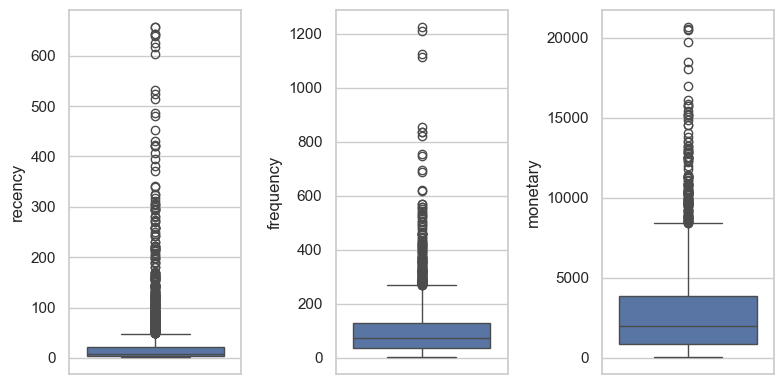

In [36]:
# Detect outliers
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(ncols= 3, figsize= (8, 4))
sns.boxplot(rfm_df['recency'], ax= axs[0])
sns.boxplot(rfm_df['frequency'], ax= axs[1])
sns.boxplot(rfm_df['monetary'], ax= axs[2])
plt.tight_layout()

> R,F,M values need outliers trimming

In [37]:
def outlier_metrics(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr

    outliers = series[(series < lower) | (series > upper)]
    pct_outliers = len(outliers) / len(series) * 100

    # Median Absolute Deviation (manual)
    mad = np.median(np.abs(series - series.median()))

    max_distance = (outliers - series.median()).abs().max() / mad if mad != 0 else np.nan

    return pct_outliers, max_distance

In [39]:
pct, wildness = outlier_metrics(rfm_df['recency'])
print(f"Outliers: {pct:.2f}% | Wildness: {wildness:.2f} MAD")

pct, wildness = outlier_metrics(rfm_df['frequency'])
print(f"Outliers: {pct:.2f}% | Wildness: {wildness:.2f} MAD")

pct, wildness = outlier_metrics(rfm_df['monetary'])
print(f"Outliers: {pct:.2f}% | Wildness: {wildness:.2f} MAD")

Outliers: 13.68% | Wildness: 108.50 MAD
Outliers: 5.52% | Wildness: 26.84 MAD
Outliers: 5.12% | Wildness: 14.28 MAD


In [48]:
# Begin with the most skewed feature : Recency
# Print outlier threshold
print('Outlier threshold:')
print("{:,}".format(int(rfm_df['recency'].quantile(0.85))))

# Remove outliers using percentiles
rfm_no_outliers = rfm_df[
    (rfm_df['recency'] <= rfm_df['recency'].quantile(0.85))
].copy()

Outlier threshold:
42


In [50]:
# Next : Frequency
# Print outlier threshold
print('Outlier threshold:')
print("{:,}".format(int(rfm_no_outliers['frequency'].quantile(0.95))))

# Remove outliers using percentiles
rfm_no_outliers = rfm_no_outliers[
    (rfm_no_outliers['frequency'] <= rfm_no_outliers['frequency'].quantile(0.95))
].copy()

Outlier threshold:
294


In [52]:
# Last : Monetary
# Print outlier threshold
print('Outlier threshold:')
print("{:,}".format(int(rfm_no_outliers['monetary'].quantile(0.95))))

# Remove outliers using percentiles
rfm_no_outliers = rfm_no_outliers[
    (rfm_no_outliers['monetary'] <= rfm_no_outliers['monetary'].quantile(0.95))
].copy()

Outlier threshold:
7,801


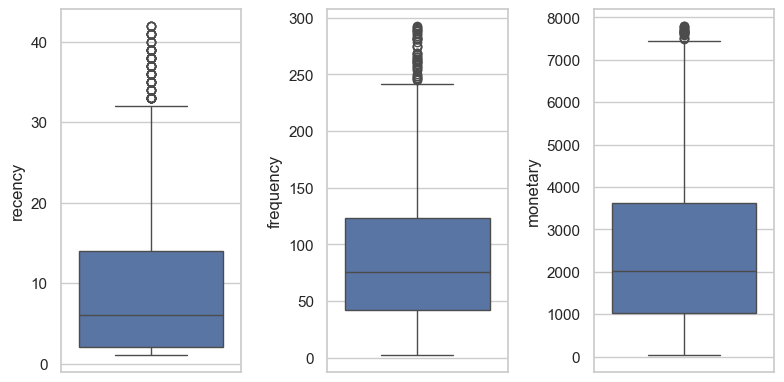

In [53]:
# Detect outliers
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(ncols= 3, figsize= (8, 4))
sns.boxplot(rfm_no_outliers['recency'], ax= axs[0])
sns.boxplot(rfm_no_outliers['frequency'], ax= axs[1])
sns.boxplot(rfm_no_outliers['monetary'], ax= axs[2])
plt.tight_layout()

> The distribution is not skewed anymore

In [66]:
100 - len(rfm_no_outliers) / len(rfm_df) * 100

23.200000000000003

> 23% of the rfm-per-customer data removed due to outliers

In [54]:
rfm_no_outliers.to_parquet(
    "data/staging/the_complete_journey_rfm_no_outlier.parquet",
    index=False,
    engine="pyarrow",
    compression="snappy"
)

# 4. Calculate RFM Scores

In [55]:
rfm_df_score = rfm_no_outliers.copy()

In [56]:
# Calculate RFM scores using quintiles
rfm_df_score['r_score'] = pd.qcut(rfm_df['recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm_df_score['f_score'] = pd.qcut(rfm_df['frequency'], 5, labels=[1,2,3,4,5]).astype(int)
rfm_df_score['m_score'] = pd.qcut(rfm_df['monetary'], 5, labels=[1,2,3,4,5]).astype(int)

In [57]:
# Get the mean scores of Monetary and Frequency
rfm_df_score['fm_score'] = rfm_df_score[['f_score','m_score']].sum(axis=1)

In [58]:
# Re bin the fm score
rfm_df_score['fm_score'] = pd.cut(
    rfm_df_score['fm_score'],
    bins=[1, 3, 5, 6, 8, 10],
    labels=[1, 2, 3, 4, 5]
).astype(int)
rfm_df_score.head()

,household_key,recency,frequency,monetary,r_score,f_score,m_score,fm_score
0,1,6,86,4330.16,3,3,4,4
2,3,9,46,2519.75,3,2,4,3
4,5,9,39,757.07,3,2,2,2
5,6,5,242,5613.98,4,5,5,5
6,7,3,59,3350.77,4,3,4,4


# 5. Classic RFM Segments

In [59]:
rfm_classic = rfm_df_score.copy()

In [60]:
# Define rule table
rfm_rule_table = pd.DataFrame([
    {"segment": "1. Champions",         "r_min": 5,   "r_max": 5,   "m_min": 4,   "m_max": 5},
    {"segment": "2. Loyalist",          "r_min": 3,   "r_max": 4,   "m_min": 4,   "m_max": 5},
    {"segment": "3. Potential Loyalist","r_min": 4,   "r_max": 5,   "m_min": 2,   "m_max": 3},
    {"segment": "4. New Customers",     "r_min": 5,   "r_max": 5,   "m_min": 1,   "m_max": 1},
    {"segment": "5. Promising",         "r_min": 4,   "r_max": 4,   "m_min": 1,   "m_max": 1},
    {"segment": "6. Need Attention",    "r_min": 3,   "r_max": 3,   "m_min": 3,   "m_max": 3},
    {"segment": "7. About To Sleep",    "r_min": 3,   "r_max": 3,   "m_min": 1,   "m_max": 2},
    {"segment": "8. Can't Lose",        "r_min": 1,   "r_max": 2,   "m_min": 5,   "m_max": 5},
    {"segment": "9. At Risk",           "r_min": 1,   "r_max": 2,   "m_min": 3,   "m_max": 4},
    {"segment": "10. Hibernating",      "r_min": 1,   "r_max": 2,   "m_min": 1,   "m_max": 2},
])
rfm_rule_table

,segment,r_min,r_max,m_min,m_max
0,1. Champions,5,5,4,5
1,2. Loyalist,3,4,4,5
2,3. Potential Loyalist,4,5,2,3
3,4. New Customers,5,5,1,1
4,5. Promising,4,4,1,1
5,6. Need Attention,3,3,3,3
6,7. About To Sleep,3,3,1,2
7,8. Can't Lose,1,2,5,5
8,9. At Risk,1,2,3,4
9,10. Hibernating,1,2,1,2


In [61]:
# Row-wise segmentation
conditions = []
choices = []

for _, rule in rfm_rule_table.iterrows():
    cond = (
        (rfm_classic['r_score'] >= rule['r_min']) & (rfm_classic['r_score'] <= rule['r_max']) &
        (rfm_classic['fm_score'] >= rule['m_min']) & (rfm_classic['fm_score'] <= rule['m_max'])
    )
    conditions.append(cond)
    choices.append(rule['segment'])
    
rfm_classic['rfm_classic_segment'] = np.select(conditions, choices, default='Unclassified')

In [62]:
rfm_classic.head(10)

,household_key,recency,frequency,monetary,r_score,f_score,m_score,fm_score,rfm_classic_segment
0,1,6,86,4330.16,3,3,4,4,2. Loyalist
2,3,9,46,2519.75,3,2,4,3,6. Need Attention
4,5,9,39,757.07,3,2,2,2,7. About To Sleep
5,6,5,242,5613.98,4,5,5,5,2. Loyalist
6,7,3,59,3350.77,4,3,4,4,2. Loyalist
7,8,6,107,5262.07,3,4,5,5,2. Loyalist
8,9,23,20,787.42,2,1,2,1,10. Hibernating
9,10,27,9,214.34,2,1,1,1,10. Hibernating
12,13,3,174,7738.46,4,5,5,5,2. Loyalist
13,14,8,116,2360.77,3,4,3,4,2. Loyalist


In [63]:
rfm_classic['rfm_classic_segment'].value_counts().sort_index()

rfm_classic_segment
1. Champions             308
10. Hibernating          367
2. Loyalist              438
3. Potential Loyalist    263
4. New Customers          45
5. Promising              52
6. Need Attention         62
7. About To Sleep        174
8. Can't Lose             41
9. At Risk               170
Name: count, dtype: int64

# 6. Visualize Classic RFM Segments

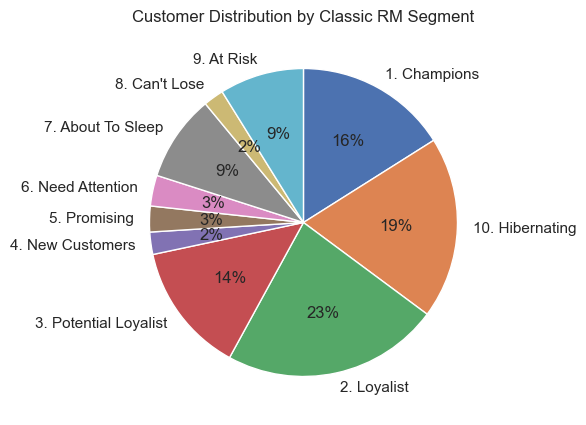

In [64]:
# Plot pie chart to show pct of each rm_segment
rfm_classic['rfm_classic_segment'].value_counts().sort_index(ascending=True).plot.pie(
    figsize=(6, 5),
    autopct='%1.0f%%',
    startangle=90,
    counterclock=False,
    ylabel='',  # Removes the default y-label
    title='Customer Distribution by Classic RM Segment'
)
plt.show()

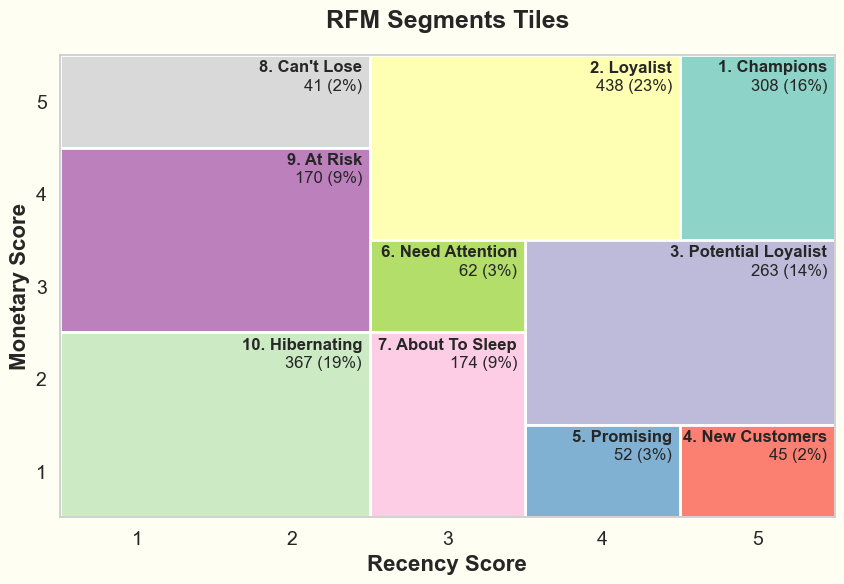

In [65]:
# Prepare colors for segments
unique_segments = rfm_rule_table['segment'].tolist()
n_segments = len(unique_segments)
cmap = plt.colormaps.get_cmap('Set3')  # Softer palette
colors = [cmap(i / n_segments) for i in range(n_segments)]
segment_colors = {seg: colors[i] for i, seg in enumerate(unique_segments)}

# Total number of customers
total_customers = len(rfm_classic)

plt.figure(figsize=(10, 6), facecolor='#FFFEF2')
ax = plt.gca()
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xticks(range(1, 6))
ax.set_yticks(range(1, 6))
ax.set_xlabel('Recency Score', fontsize=16, fontweight='bold')
ax.set_ylabel('Monetary Score', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_title(f'RFM Segments Tiles', fontsize=18, fontweight='bold', pad=20)

for _, row in rfm_rule_table.iterrows():
    segment = row['segment']
    r_min, r_max = row['r_min'], row['r_max']
    m_min, m_max = row['m_min'], row['m_max']

    # Calculate width and height of the rectangle
    width = r_max - r_min + 1
    height = m_max - m_min + 1

    # Draw rectangle for the segment
    rect = Rectangle((r_min - 0.5, m_min - 0.5), width, height,
                     facecolor=segment_colors[segment],
                     edgecolor='white', linewidth=2)
    ax.add_patch(rect)

    # Filter customers in this segment
    subset = rfm_classic[rfm_classic['rfm_classic_segment'] == segment]
    count = len(subset)
    percent = count / total_customers * 100

    # Position text at top-right corner with padding
    text_x = r_max + 0.45
    text_y = m_max + 0.45

    # Add segment name and count + percentage
    ax.text(text_x, text_y, segment, ha='right', va='top', wrap=True, fontweight='bold')
    ax.text(text_x, text_y - 0.2, f"{count:,} ({percent:.0f}%)", ha='right', va='top', wrap=True, fontsize=12)

plt.grid(False)
plt.show()